# Week-1 Assignment

# **Gotta catch 'em all !**

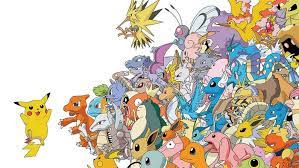

**Welcome to your first graded assignment! Hope that you are excited to implement and test everything you have learnt up until now. The dataset which you'll use includes information about Pokemons.**

**We have got an interesting set of questions for you to get a basic understanding of pandas and data visualization libraries. GOOD LUCK!**


***Let's get started with importing numpy, pandas, seaborn and matplotlib!***

Note - matplotlib should be imported with the command :

 `import matplotlib.pyplot as plt`

### 1) Start by importing all important libraries
For eg, "import numpy as np"

In [32]:
#your code here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### 2) Read the csv file and assign it to a variable .

In [33]:
#your code here
pok = pd.read_csv('W1_Pokemon.csv')

### 3) Display shape of dataframe
Expected Output - (800, 13)

In [34]:
#your code here
print(pok.shape)

(800, 13)


### 4) Print all columns of dataframe





Return an array containing names of all the columns.

In [35]:
#your code here
pok.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

### 5) Remove the column '#' and update the dataframe.

In [36]:
#your code here
df =pok.drop('#', axis = 1)
df.columns

Index(['Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

### 6) Set the 'Name' column as the index of dataframe

In [37]:
#your code here
df = pok.set_index('Name')

###  7) Print a list of all the unique Type-1 powers

In [38]:
#your code here
print(df['Type 1'].unique())

['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Poison' 'Electric' 'Ground'
 'Fairy' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Ice' 'Dragon' 'Dark' 'Steel'
 'Flying']


### 8) Create a column which contains the Type 1 and Type 2 abilities of pokemons, seperated with a '+'' sign. Also, display the no. of pokemons that have type-1 power as 'Psychic' and type 2 power as 'Flying' using this new column.

In [45]:
# #your code here
df['new'] = df['Type 1'] + ' + ' + df['Type 2']
df.to_csv('W1_2.csv', index=False, columns = ['Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary', 'new'])

print(df)

print(df[(df['new']=='Psychic + Flying')].shape[0])


                         #   Type 1  Type 2  Total  HP  Attack  Defense  \
Name                                                                      
Bulbasaur                1    Grass  Poison    318  45      49       49   
Ivysaur                  2    Grass  Poison    405  60      62       63   
Venusaur                 3    Grass  Poison    525  80      82       83   
VenusaurMega Venusaur    3    Grass  Poison    625  80     100      123   
Charmander               4     Fire     NaN    309  39      52       43   
...                    ...      ...     ...    ...  ..     ...      ...   
Diancie                719     Rock   Fairy    600  50     100      150   
DiancieMega Diancie    719     Rock   Fairy    700  50     160      110   
HoopaHoopa Confined    720  Psychic   Ghost    600  80     110       60   
HoopaHoopa Unbound     720  Psychic    Dark    680  80     160       60   
Volcanion              721     Fire   Water    600  80     110      120   

                       S

## GRADED Questions (To be answered in the quiz)
### Try to retrieve some information from the data and answer the questions below . BEST OF LUCK !!

### 1. How many pokemons have 'Mega' in their name?

In [7]:
#your code here
pok['Name'].str.contains('Mega', na=False).sum()


np.int64(49)

### 2. What is the standard deviation of Sp. Def. in the dataset ?

In [15]:
#your code here
std_dev = pok['Sp. Def'].std()
print(std_dev)

27.82891579711745


### 3. What percentage (upto 3 decimal places) of pokemons are legendary ?

In [21]:
#your code here
legendp= ((pok['Legendary']==True).sum() / pok['Legendary'].count()) *100
print(legendp)

8.125


### 4. Name the pokemon(s) with Maximum Defense.

In [24]:
#your code here
maxdef = pok['Defense'].max()
strong= pok[pok['Defense'] == maxdef]
print(strong['Name'])

224    SteelixMega Steelix
230                Shuckle
333      AggronMega Aggron
Name: Name, dtype: object


### 5. Which poison pokemon has the strongest attack ?

In [27]:
#your code here
poison = pok[pok['Type 2'] == 'Poison']
strong = poison[poison['Attack'] == poison['Attack'].max()]
print(strong['Name'])

19    BeedrillMega Beedrill
Name: Name, dtype: object


### 6. Using seaborn make different types of plots, observe the trend and answer the questions given in the form.

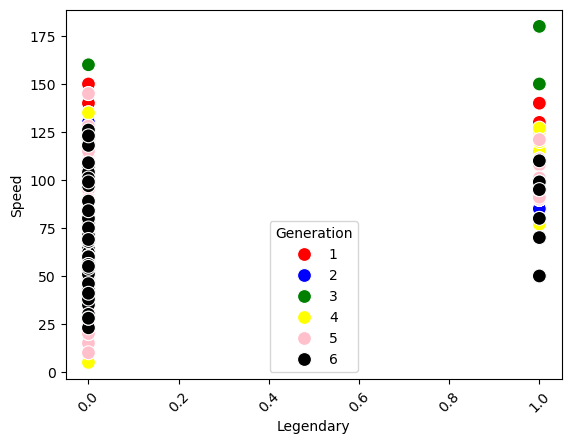

In [41]:
#your code here
import seaborn as sns
from matplotlib import pyplot as plt
pok = pd.read_csv("W1_Pokemon.csv")
sns.scatterplot(data = pok, x = 'Legendary', y='Speed', hue='Generation', s= 100,palette=['red', 'blue', 'green', 'yellow', 'pink', 'black'])
plt.xticks(rotation = 45)
plt.show()


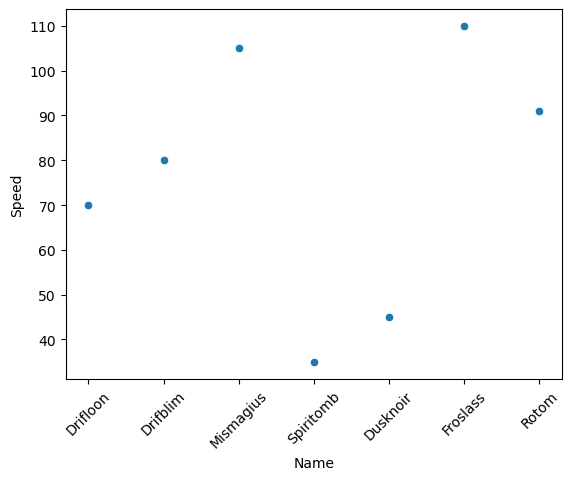

In [50]:
#your code here
ghost = pok[
    (pok['Generation']==4) &
    (pok['Legendary']==False) &
    ((pok['Type 1']=='Ghost') | (pok['Type 2']=='Ghost'))
]

sns.scatterplot(data=ghost, x='Name', y='Speed')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Attack', ylabel='Defense'>

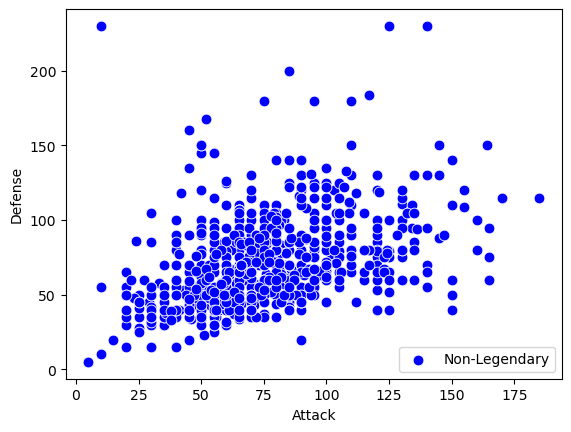

In [55]:
#your code here
sns.scatterplot(
    data=pok[pok['Legendary']==False], x='Attack', y='Defense',color='blue', s=60, label='Non-Legendary')


### 7. Which is the second fastest non-legendary 'Ghost' type pokemon from 4th generation ?

In [53]:
#your code here
ghost = ghost.sort_values(by='Speed', ascending=False)

print("\nSecond fastest Pokémon:", ghost.iloc[1]['Name'])


Second fastest Pokémon: Mismagius


### 8. How many non-legendary pokemons have stronger defence but weaker attack than Charizard?

In [58]:
#your code here
chari = pok[pok['Name'] == 'Charizard'].iloc[0]

count = pok[
    (pok['Legendary'] == False) &
    (pok['Defense'] > chari['Defense']) &
    (pok['Attack'] < chari['Attack'])
].shape[0]

print(count)

116



## ***Bonus Questions***
## Here are some bonus questions that you can try further !

### These questions are UNGRADED, and are given as an extra exercise.

### Which pokemon has the highest combined value of Attack and Sp. Atk ?

In [ ]:
#your code here


### Which type of legendary pokemons are the most common?

In [ ]:
#your code here


### How many generation-3, non-legendary pokemons have higher HP than the weakest generation-6, legendary pokemon?

In [ ]:
#your code here


### Print out the third slowest pokemon(s) in the dataset.

In [ ]:
#your code here


### Which pokemon type has the highest average HP?

In [ ]:
#your code here
